In [29]:
import numpy as np
import cvxpy as cp
from scipy.spatial.transform import Rotation
import tqdm.notebook as tqdm
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

In [30]:
from analysis import *
from ellipsoid_fit import *

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.spatial.transform import Rotation
np.set_printoptions(precision=3, suppress=True)

In [31]:

def normalize(vec):
    if len(vec.shape) == 1:
        return vec / np.linalg.norm(vec)
    return vec / np.linalg.norm(vec, axis=1, keepdims=True)

def load_data():
    data = process_file_to_raw_data("magacc_readings_8.txt")
    mag = data[:,:3]
    acc = data[:,3:]

    norm = np.linalg.norm(acc, 2, axis=1)
    idcs = np.isclose(norm, 9.8, atol=0.4)

    mag = mag[idcs]
    acc = acc[idcs]

    mag = np.array(mag)
    acc = np.array(acc)
    return mag, acc



In [32]:
import numpy as np


# q = [Q00,Q11,Q22,Q33,Q01,Q02,Q03,Q12,Q13,Q23]
Q_PAIRS = (
    (0, 0), (1, 1), (2, 2), (3, 3),
    (0, 1), (0, 2), (0, 3),
    (1, 2), (1, 3), (2, 3),
)


def quadratic_features(x):
    """Returns phi such that phi @ q = x.T @ Q @ x."""
    return np.array([
        x[i] * x[j] if i == j else 2.0 * x[i] * x[j]
        for i, j in Q_PAIRS
    ])


def gram_features_jacobian(W):
    """
    q(W) = vech(W.T @ W)
    J[k,j] = d q_k / d vec_row(W)_j
    """
    Q = W.T @ W
    q = np.array([Q[i, j] for i, j in Q_PAIRS])
    J = np.zeros((10, 12))

    for k, (i, j) in enumerate(Q_PAIRS):
        for row in range(3):
            wi = 4 * row + i
            wj = 4 * row + j

            if i == j:
                J[k, wi] = 2.0 * W[row, i]
            else:
                J[k, wi] = W[row, j]
                J[k, wj] = W[row, i]

    return q, J


class StreamingMagCalibration:
    def __init__(self, T, alpha=1.0, beta=1.0):
        self.T = float(T)
        self.alpha = float(alpha)
        self.beta = float(beta)

        self.Ha = np.zeros((12, 12))
        self.ga = np.zeros(12)
        self.ca = 0.0

        self.Hn = np.zeros((10, 10))
        self.gn = np.zeros(10)
        self.cn = 0.0

        self.weight_sum = 0.0

    def update(self, mag_raw, acc, weight=1.0):
        if weight <= 0:
            return False

        mag_raw = np.asarray(mag_raw, dtype=float)
        acc = np.asarray(acc, dtype=float)

        acc_norm = np.linalg.norm(acc)
        if not np.isfinite(acc_norm) or acc_norm == 0:
            return False

        acc = acc / acc_norm
        x = np.r_[mag_raw, 1.0]

        z = np.kron(acc, x)
        phi = quadratic_features(x)
        w = float(weight)

        self.Ha += w * np.outer(z, z)
        self.ga += w * self.T * z
        self.ca += w * self.T**2

        self.Hn += w * np.outer(phi, phi)
        self.gn += w * phi
        self.cn += w

        self.weight_sum += w
        return True

    def initialize(self, method="lstsq", rcond=1e-12):
        """Solve the beta=0 presolve."""
        if self.weight_sum <= 0:
            return None

        if method == "lstsq":
            w, _, rank, _ = np.linalg.lstsq(
                self.Ha, self.ga, rcond=rcond
            )
            if rank < 12:
                return None

        elif method == "eigen":
            eigenvalues, V = np.linalg.eigh(
                0.5 * (self.Ha + self.Ha.T)
            )
            threshold = rcond * max(eigenvalues[-1], 1.0)

            if np.count_nonzero(eigenvalues > threshold) < 12:
                return None

            w = V @ ((V.T @ self.ga) / eigenvalues)

        else:
            raise ValueError("method must be 'lstsq' or 'eigen'")

        return w if np.all(np.isfinite(w)) else None

    def model(self, w):
        W = w.reshape(3, 4)
        q, Jq = gram_features_jacobian(W)
        scale = 1.0 / self.weight_sum

        objective = 0.5 * scale * (
            self.alpha * (
                w @ self.Ha @ w
                - 2.0 * self.ga @ w
                + self.ca
            )
            + self.beta * (
                q @ self.Hn @ q
                - 2.0 * self.gn @ q
                + self.cn
            )
        )

        gradient = scale * (
            self.alpha * (self.Ha @ w - self.ga)
            + self.beta * Jq.T @ (self.Hn @ q - self.gn)
        )

        hessian_gn = scale * (
            self.alpha * self.Ha
            + self.beta * Jq.T @ self.Hn @ Jq
        )

        return objective, gradient, hessian_gn

    def solve(
        self,
        init_method="lstsq",
        max_iter=50,
        tol=1e-10,
        damping=1e-6,
    ):
        w = self.initialize(init_method)
        if w is None:
            return None, {
                "success": False,
                "reason": "presolve failed or was rank deficient",
            }

        objective, gradient, H = self.model(w)
        lm = float(damping)

        for iteration in range(max_iter):
            if np.linalg.norm(gradient, ord=np.inf) <= tol:
                break

            diagonal = np.maximum(np.diag(H), 1e-12)
            accepted = False

            for _ in range(20):
                try:
                    step = np.linalg.solve(
                        H + lm * np.diag(diagonal),
                        -gradient,
                    )
                except np.linalg.LinAlgError:
                    return None, {
                        "success": False,
                        "reason": "linear solve failed",
                    }

                new_objective, new_gradient, new_H = self.model(w + step)

                if (
                    np.isfinite(new_objective)
                    and new_objective < objective
                ):
                    w += step
                    objective = new_objective
                    gradient = new_gradient
                    H = new_H
                    lm = max(lm / 3.0, 1e-15)
                    accepted = True
                    break

                lm *= 10.0

            if not accepted:
                return None, {
                    "success": False,
                    "reason": "could not find a descent step",
                    "iterations": iteration,
                }

            if np.linalg.norm(step) <= tol * (1.0 + np.linalg.norm(w)):
                break

        return w.reshape(3, 4), {
            "success": True,
            "iterations": iteration + 1,
            "objective": objective,
            "gradient_inf": np.linalg.norm(gradient, ord=np.inf),
        }

In [33]:
from scipy.spatial.transform import Rotation

noise = 0.005
rng = np.random.default_rng()

m_lab = np.array([0.4, -0.3, 0.6])
m_lab /= np.linalg.norm(m_lab)

a_lab = np.array([0.0, 0.0, -1.0])
a_lab /= np.linalg.norm(a_lab)
T = float(a_lab @ m_lab)

D_true = Rotation.random(random_state=rng).as_matrix() @ np.diag(0.3 + 10 * np.random.rand(3))
shift_true = (np.random.rand(3) * 2 - 1) * 5

cal = StreamingMagCalibration(T, alpha=1.0, beta=0.0)

mag = []
acc = []
for _ in range(100):
    R = Rotation.random().as_matrix()

    a = R @ a_lab + noise * rng.normal(size=3)
    mag_true = R @ m_lab + noise * rng.normal(size=3)
    mag_raw = (
        # D_true @ mag_true
        mag_true 
        + shift_true
        + noise * rng.normal(size=3)
    )

    mag.append(mag_raw)
    acc.append(a)
    assert cal.update(mag_raw, a)
mag = np.array(mag)
acc = np.array(mag)

W_hat, info = cal.solve(init_method="eigen")

A_hat = W_hat[:, :3]
b_hat = W_hat[:, 3]

A_expected = np.linalg.inv(D_true)
b_expected = -A_expected @ shift_true

# print(info)
# print("A error:", np.linalg.norm(A_hat - A_expected))
# print("b error:", np.linalg.norm(b_hat - b_expected))

In [34]:
D_true

array([[ 1.578, -3.456,  0.82 ],
       [ 1.384,  1.442,  5.077],
       [-2.532, -1.366,  3.287]])

In [35]:
# W_hat = cal.initialize()
# W_hat = W_hat.reshape(3,4)
# A_hat = W_hat[:, :3]
# b_hat = W_hat[:, 3]

In [36]:
%matplotlib inline

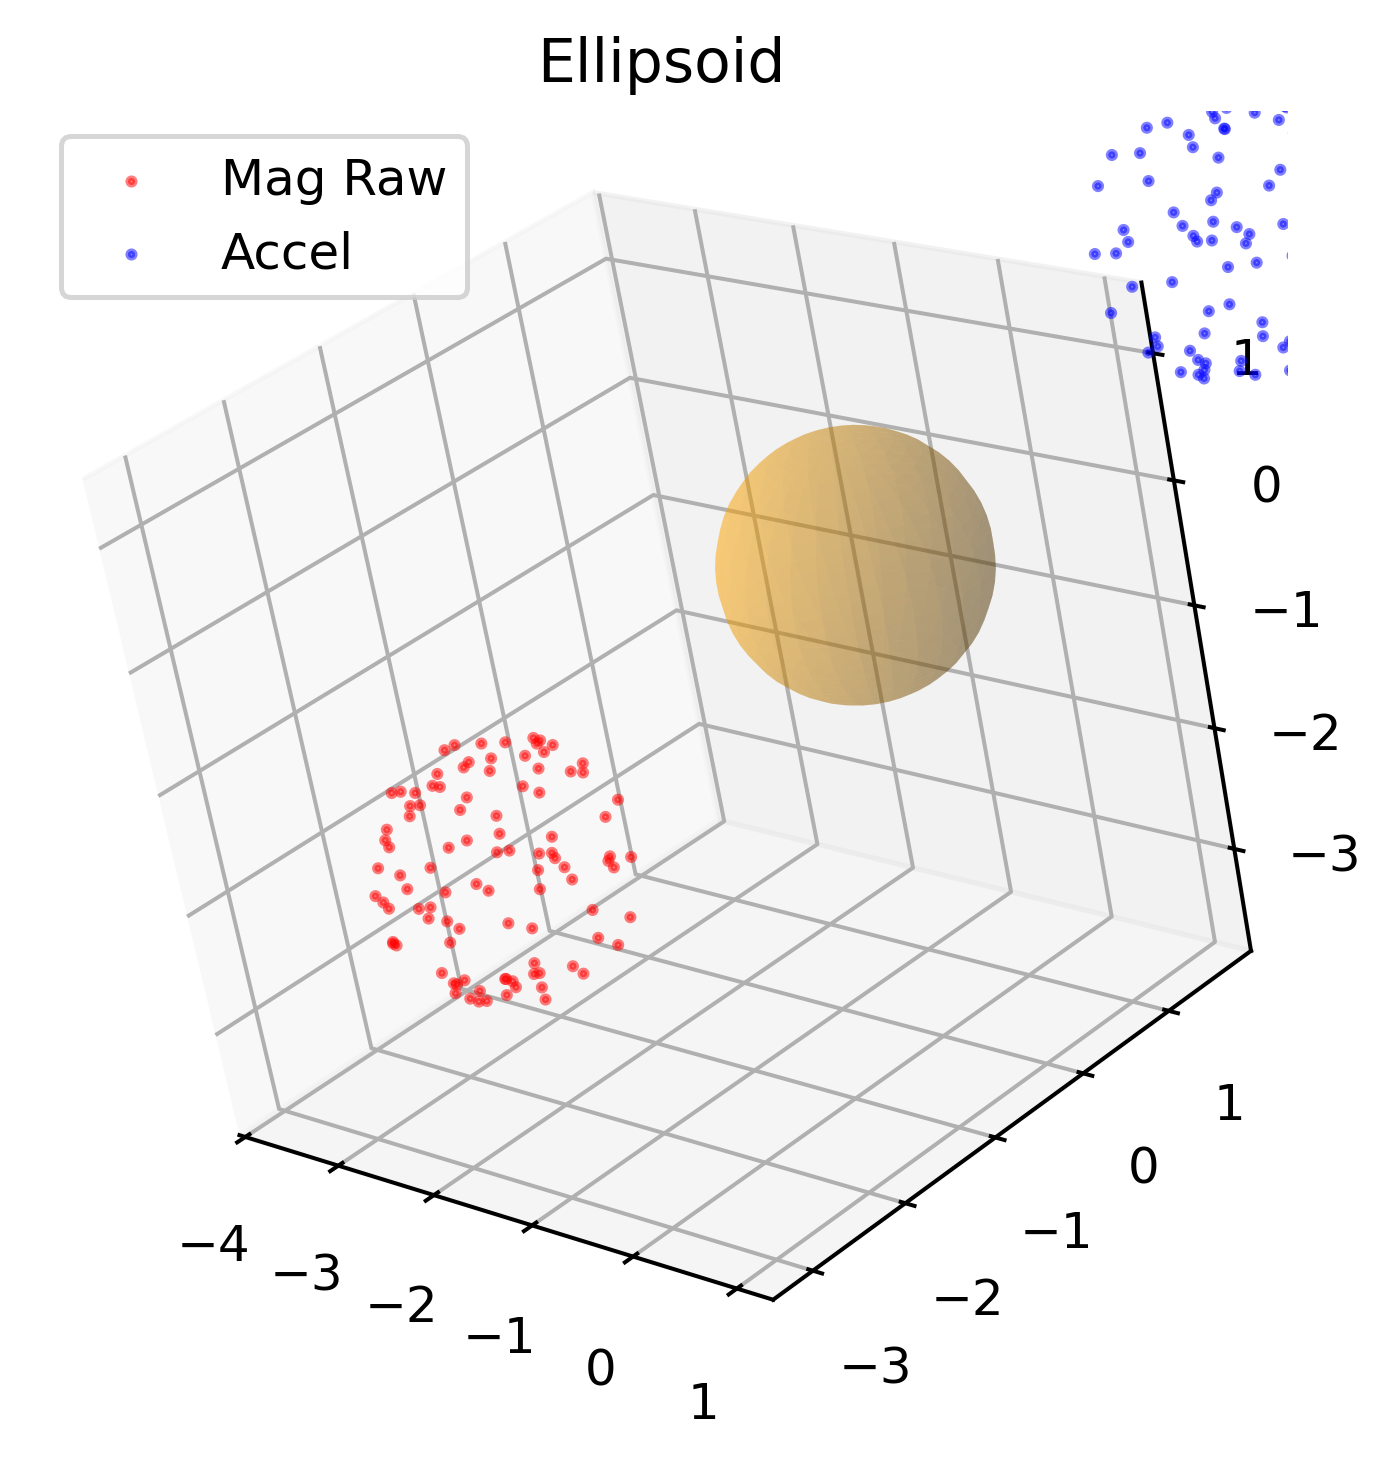

<Figure size 1440x1440 with 0 Axes>

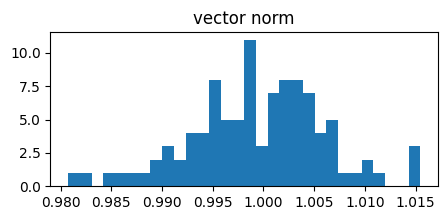

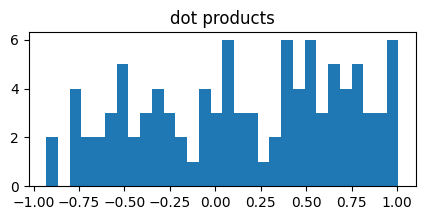

In [37]:
M = mag @ A_hat.T + b_hat
A = normalize(acc)

plt.clf()
norms = np.linalg.norm(M, axis=1)
plt.figure(figsize=(5,2))
plt.hist(norms, 30)
plt.title("vector norm")
plt.show()

dots = np.array([m @ a for m,a in zip(M,A)])
plt.figure(figsize=(5,2))
plt.hist(dots, 30)
plt.title("dot products")
plt.show()

In [38]:
%matplotlib widget

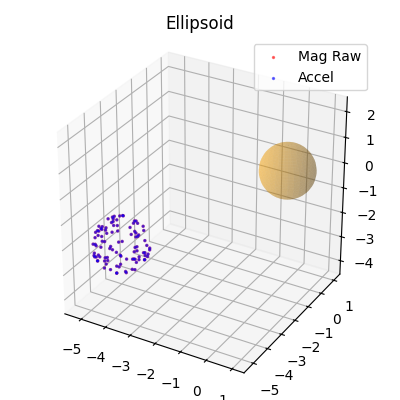

In [39]:
# gravity frame
acc_normalized = acc # / np.linalg.norm(acc, axis=1, keepdims=True)
detrans_normalized = mag

fig = plt.figure(figsize=(4, 4))

ax1 = fig.add_subplot(111, projection='3d')
ax1.scatter(*mag.T, c='red', marker='o', s=2, alpha=0.5, label='Mag Raw')
plot_ellipsoid(ax1, center=np.zeros(3), R=np.eye(3), radii=np.ones(3))

ax1.scatter(*acc_normalized.T, c='blue', marker='o', s=2, alpha=0.5, label='Accel')

plt.legend()
plt.tight_layout()
plt.show()